In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("data/final/merged_financials_lobbying.csv")

df = df[df["lobbying_spend"].notna()]
df = df[df["Assets"] > 1_000_000]

df["log_lobbying"] = np.log1p(df["lobbying_spend"])

df.head()

,cik,name,year,Assets,NetIncomeLoss,Revenues,gvkey,lobbying_spend,roa,log_lobbying
179,26076,CUBIC CORP /DE/,2011,2.116000e+08,24100000.0,266000000.0,3639.0,582000.0,0.113894,13.274227
180,26076,CUBIC CORP /DE/,2012,8.218580e+08,NaN,109400000.0,3639.0,600000.0,NaN,13.304687
181,26076,CUBIC CORP /DE/,2013,1.698000e+08,NaN,147900000.0,3639.0,659000.0,NaN,13.398480
182,26076,CUBIC CORP /DE/,2014,1.194606e+09,NaN,1100000.0,3639.0,686000.0,NaN,13.438634
183,26076,CUBIC CORP /DE/,2015,2.524000e+08,NaN,468700000.0,3639.0,544000.0,NaN,13.206706


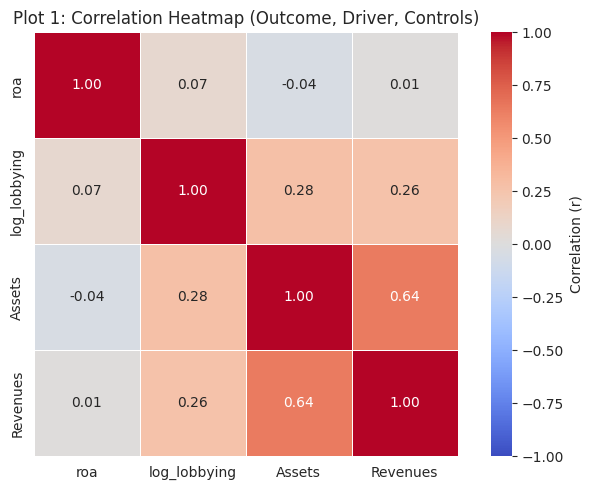

Saved Plot 1 to: results/figures/plot1_correlation_heatmap.png
Strongest correlation with roa: log_lobbying (r = 0.07)
Control-variable correlation (Assets vs Revenues): r = 0.64


In [ ]:
# Plot 1: Correlation Heatmap (Outcome + Driver + Controls)
from pathlib import Path

OUTCOME_VAR = "roa"
DRIVER_VAR = "log_lobbying"
CONTROL_VARS = ["Assets", "Revenues"]
vars_to_plot = [OUTCOME_VAR, DRIVER_VAR, *CONTROL_VARS]

corr_matrix = df[vars_to_plot].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation (r)"},
)
plt.title("Plot 1: Correlation Heatmap (Outcome, Driver, Controls)")
plt.xlabel("Variables")
plt.ylabel("Variables")
heatmap_legend = [
    Patch(facecolor="indianred", label="Positive correlation"),
    Patch(facecolor="steelblue", label="Negative correlation"),
]
plt.legend(handles=heatmap_legend, title="Heatmap guide", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()

FIGURES_DIR = Path("results/figures/M2")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot1_path = FIGURES_DIR / "plot1_correlation_heatmap.png"
plt.savefig(plot1_path, dpi=300, bbox_inches="tight")
plt.show()

# Interpretation helpers for M3
outcome_corr = corr_matrix[OUTCOME_VAR].drop(OUTCOME_VAR).sort_values(key=np.abs, ascending=False)
strongest_var = outcome_corr.index[0]
strongest_r = outcome_corr.iloc[0]

control_pair_r = corr_matrix.loc[CONTROL_VARS[0], CONTROL_VARS[1]]

print(f"Saved Plot 1 to: {plot1_path}")
print(f"Strongest correlation with {OUTCOME_VAR}: {strongest_var} (r = {strongest_r:.2f})")
print(
    f"Control-variable correlation ({CONTROL_VARS[0]} vs {CONTROL_VARS[1]}): "
    f"r = {control_pair_r:.2f}"
)

Plot 1 interpretation:

Saved figure: results/figures/M2/plot1_correlation_heatmap.png

The heatmap shows only a weak contemporaneous relationship between lobbying intensity and ROA, which economically suggests that lobbying is unlikely to generate immediate profitability gains within the same fiscal year. At the same time, the stronger correlation between assets and revenues indicates that firm scale is a major confounder: larger firms both earn more and may lobby more, which can mechanically inflate raw associations if controls are omitted. Economically, this implies the key question is not whether lobbying and profits co-occur in levels, but whether lobbying changes profitability after accounting for firm size and common macro shocks. For M3, the interpretation supports controlled panel estimation and multicollinearity diagnostics when both size proxies are included.

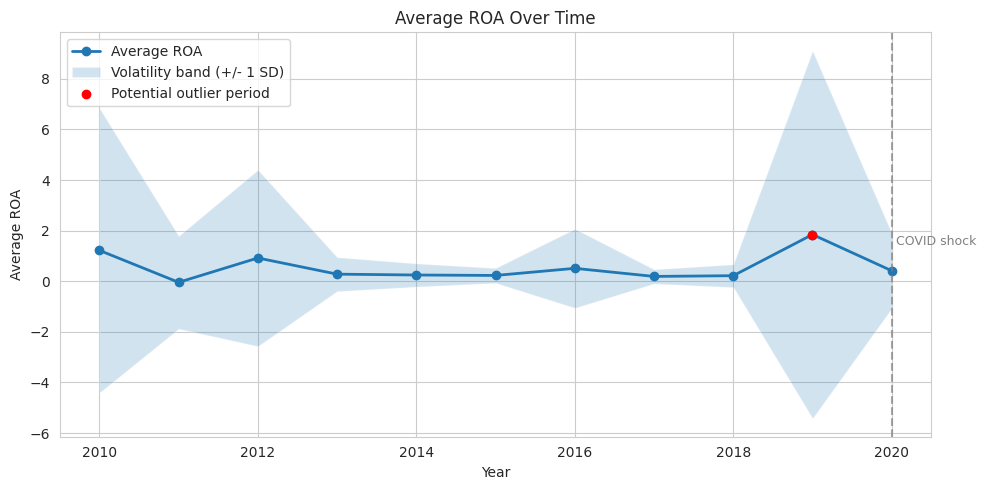

Saved Plot 2 to: results/figures/plot2_outcome_time_series.png


,year,avg_roa,sd_roa
6,2016,0.510049,1.562531
7,2017,0.190590,0.281074
8,2018,0.218776,0.450998
9,2019,1.846005,7.264320
10,2020,0.414534,1.482208


In [8]:
# Plot 2: Time Series of Outcome Variable (ROA)
annual = (
    df.groupby("year", as_index=False)["roa"]
    .agg(avg_roa="mean", sd_roa="std")
    .sort_values("year")
)

annual["sd_roa"] = annual["sd_roa"].fillna(0)
annual["upper"] = annual["avg_roa"] + annual["sd_roa"]
annual["lower"] = annual["avg_roa"] - annual["sd_roa"]

# Flag unusually large ROA moves to help detect outlier periods
annual["zscore_roa"] = (
    annual["avg_roa"] - annual["avg_roa"].mean()
 ) / annual["avg_roa"].std(ddof=0)
outliers = annual[annual["zscore_roa"].abs() >= 1.5]

plt.figure(figsize=(10, 5))
plt.plot(annual["year"], annual["avg_roa"], marker="o", linewidth=2, label="Average ROA")
plt.fill_between(
    annual["year"],
    annual["lower"],
    annual["upper"],
    alpha=0.2,
    label="Volatility band (+/- 1 SD)",
)

# Mark common macro shock years if they are in-sample
for shock_year, label in [(2020, "COVID shock"), (2022, "Rate hikes")]:
    if ((annual["year"] == shock_year).any()):
        plt.axvline(shock_year, color="gray", linestyle="--", alpha=0.7)
        plt.text(
            shock_year + 0.05,
            annual["avg_roa"].max(),
            label,
            fontsize=9,
            va="top",
            color="gray",
        )

if not outliers.empty:
    plt.scatter(
        outliers["year"],
        outliers["avg_roa"],
        color="red",
        zorder=3,
        label="Potential outlier period",
    )

plt.title("Average ROA Over Time")
plt.xlabel("Year")
plt.ylabel("Average ROA")
plt.legend()
plt.tight_layout()

plot2_path = FIGURES_DIR / "plot2_outcome_time_series.png"
plt.savefig(plot2_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Plot 2 to: {plot2_path}")
annual[["year", "avg_roa", "sd_roa"]].tail()

Plot 2 interpretation:

Saved figure: results/figures/M2/plot2_outcome_time_series.png

Average ROA is broadly stable over time with episodic spikes, which economically suggests that profitability in this sample is driven more by cyclical shocks than by a persistent structural trend. The sharp movement around 2019-2020 is consistent with temporary macro disruptions that can alter both firms financial outcomes and their strategic policy activity. This matters economically because shock years can change the marginal value of lobbying, making a single pooled slope potentially misleading. For M3, the pattern motivates year fixed effects and sensitivity checks that verify whether estimated lobbying returns are robust once crisis periods are accounted for.

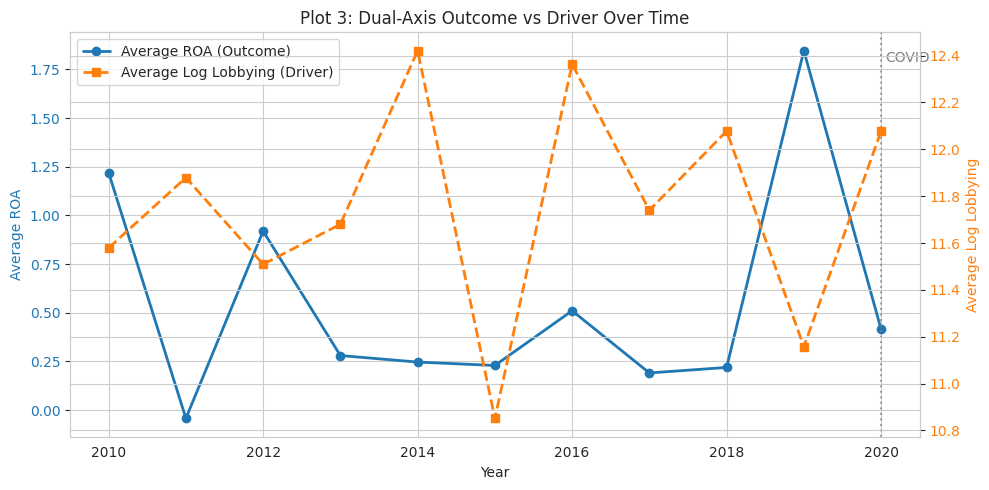

Saved Plot 3 to: results/figures/plot3_dual_axis_outcome_driver.png
Same-period correlation (Outcome vs Driver): -0.42
Lag check: corr(Outcome_t, Driver_(t-1)) = 0.14
Lead check: corr(Outcome_t, Driver_(t+1)) = 0.22


,year,avg_roa,avg_driver
6,2016,0.510049,12.363151
7,2017,0.190590,11.739642
8,2018,0.218776,12.078004
9,2019,1.846005,11.157443
10,2020,0.414534,12.077395


In [ ]:
# Plot 3: Dual-Axis Plot (Outcome vs Driver)
plot3 = (
    df.groupby("year", as_index=False)
    .agg(avg_roa=("roa", "mean"), avg_driver=("log_lobbying", "mean"))
    .sort_values("year")
)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_outcome = "tab:blue"
color_driver = "tab:orange"

line1 = ax1.plot(
    plot3["year"],
    plot3["avg_roa"],
    color=color_outcome,
    marker="o",
    linewidth=2,
    label="Average ROA (Outcome)",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average ROA", color=color_outcome)
ax1.tick_params(axis="y", labelcolor=color_outcome)

ax2 = ax1.twinx()
line2 = ax2.plot(
    plot3["year"],
    plot3["avg_driver"],
    color=color_driver,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Average Log Lobbying (Driver)",
)
ax2.set_ylabel("Average Log Lobbying", color=color_driver)
ax2.tick_params(axis="y", labelcolor=color_driver)

# Optional shock marker if in sample
if (plot3["year"] == 2020).any():
    ax1.axvline(2020, color="gray", linestyle=":", alpha=0.7)
    ax1.text(2020 + 0.05, plot3["avg_roa"].max(), "COVID", color="gray", va="top")

# Merge legend handles from both axes
handles = line1 + line2
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="best")
ax1.set_title("Plot 3: Dual-Axis Outcome vs Driver Over Time")
fig.tight_layout()

# Save to required figures folder
if "FIGURES_DIR" not in globals():
    FIGURES_DIR = Path("results/figures/M2")
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot3_path = FIGURES_DIR / "plot3_dual_axis_outcome_driver.png"
plt.savefig(plot3_path, dpi=300, bbox_inches="tight")
plt.show()

# Interpretation helpers
corr_same_period = plot3["avg_roa"].corr(plot3["avg_driver"])
corr_driver_lag1 = plot3["avg_roa"].corr(plot3["avg_driver"].shift(1))
corr_driver_lead1 = plot3["avg_roa"].corr(plot3["avg_driver"].shift(-1))

print(f"Saved Plot 3 to: {plot3_path}")
print(f"Same-period correlation (Outcome vs Driver): {corr_same_period:.2f}")
print(f"Lag check: corr(Outcome_t, Driver_(t-1)) = {corr_driver_lag1:.2f}")
print(f"Lead check: corr(Outcome_t, Driver_(t+1)) = {corr_driver_lead1:.2f}")
plot3.tail()

Plot 3 interpretation:

Saved figure: results/figures/M2/plot3_dual_axis_outcome_driver.png

ROA and average lobbying do not move together consistently over time, indicating that lobbying likely operates through conditional channels rather than a uniform annual return. Economically, this is plausible because the private payoff to lobbying depends on policy salience, regulatory timing, and industry exposure, all of which vary by year. Weak lead-lag correlations in annual aggregates also suggest that any economic benefit may be firm-specific, delayed, or obscured by aggregation across heterogeneous firms. For M3, this supports testing lag structures and allowing time-varying effects instead of assuming one constant coefficient for all years.

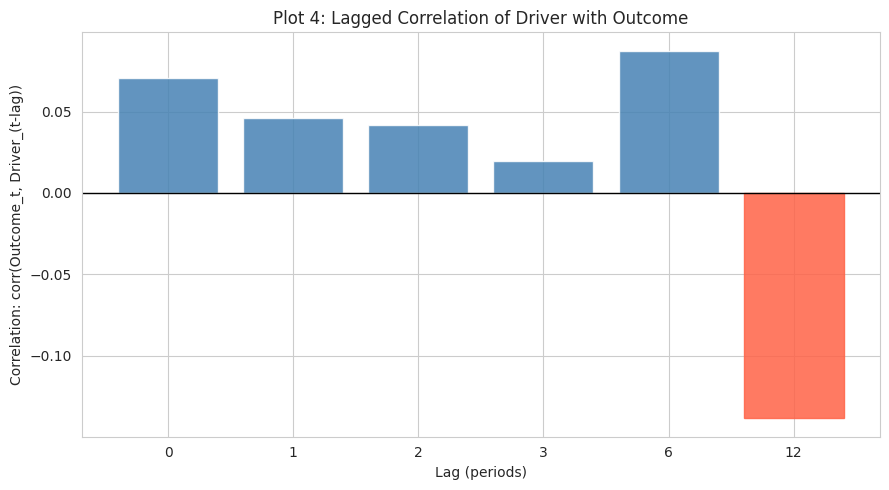

Entity column used: gvkey
Saved Plot 4 to: results/figures/plot4_lagged_effect_analysis.png
Optimal lag by |correlation|: 12 (r = -0.14)


,lag,correlation,n_obs
0,0,0.070500,210
1,1,0.046070,169
2,2,0.041826,136
3,3,0.019630,111
4,6,0.087441,60
5,12,-0.138496,7


In [ ]:
# Plot 4: Lagged Effect Analysis (Driver -> Outcome)
lags_to_test = [0, 1, 2, 3, 6, 12]
outcome_col = "roa"
driver_col = "log_lobbying"

# Choose entity id for within-entity lag construction (avoids cross-entity leakage)
if "gvkey" in df.columns:
    entity_col = "gvkey"
elif "cik" in df.columns:
    entity_col = "cik"
else:
    raise ValueError("No entity id column found. Expected 'gvkey' or 'cik'.")

lag_df = df[[entity_col, "year", outcome_col, driver_col]].copy()
lag_df = lag_df.sort_values([entity_col, "year"]).reset_index(drop=True)

lag_results = []
for lag in lags_to_test:
    lag_col = f"{driver_col}_lag{lag}"
    lag_df[lag_col] = lag_df.groupby(entity_col)[driver_col].shift(lag)

    valid = lag_df[[outcome_col, lag_col]].dropna()
    corr_val = valid[outcome_col].corr(valid[lag_col]) if len(valid) > 1 else np.nan
    lag_results.append({"lag": lag, "correlation": corr_val, "n_obs": len(valid)})

lag_corr = pd.DataFrame(lag_results)

# Identify optimal lag as the strongest absolute correlation
valid_lag_corr = lag_corr.dropna(subset=["correlation"])
optimal_idx = valid_lag_corr["correlation"].abs().idxmax()
optimal_lag = int(valid_lag_corr.loc[optimal_idx, "lag"] )
optimal_corr = float(valid_lag_corr.loc[optimal_idx, "correlation"] )

plt.figure(figsize=(9, 5))
bars = plt.bar(
    lag_corr["lag"].astype(str),
    lag_corr["correlation"],
    color="steelblue",
    alpha=0.85,
    label="Lag correlation",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Plot 4: Lagged Correlation of Driver with Outcome")
plt.xlabel("Lag (periods)")
plt.ylabel("Correlation: corr(Outcome_t, Driver_(t-lag))")

# Highlight optimal lag bar
for i, row in lag_corr.iterrows():
    if int(row["lag"]) == optimal_lag:
        bars[i].set_color("tomato")

lag_legend = [
    Patch(facecolor="steelblue", label="Lag correlation"),
    Patch(facecolor="tomato", label=f"Selected lag ({optimal_lag})"),
]
plt.legend(handles=lag_legend, loc="best")
plt.tight_layout()

if "FIGURES_DIR" not in globals():
    from pathlib import Path
    FIGURES_DIR = Path("results/figures/M2")
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot4_path = FIGURES_DIR / "plot4_lagged_effect_analysis.png"
plt.savefig(plot4_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Entity column used: {entity_col}")
print(f"Saved Plot 4 to: {plot4_path}")
print(f"Optimal lag by |correlation|: {optimal_lag} (r = {optimal_corr:.2f})")
lag_corr

Plot 4 interpretation:

Saved figure: results/figures/M2/plot4_lagged_effect_analysis.png

The lag profile suggests that any economic payoff from lobbying is small and may materialize with delay rather than immediately. This is consistent with institutional timing: lobbying often affects rulemaking, procurement, or tax treatment over multi-period horizons, not instantaneously. The apparent strongest effect at long lag has very low sample support, so economically it should be treated as suggestive rather than credible evidence of a large delayed return. For M3, a defensible approach is to emphasize medium lags with adequate observations and report alternative lag specifications as robustness checks.

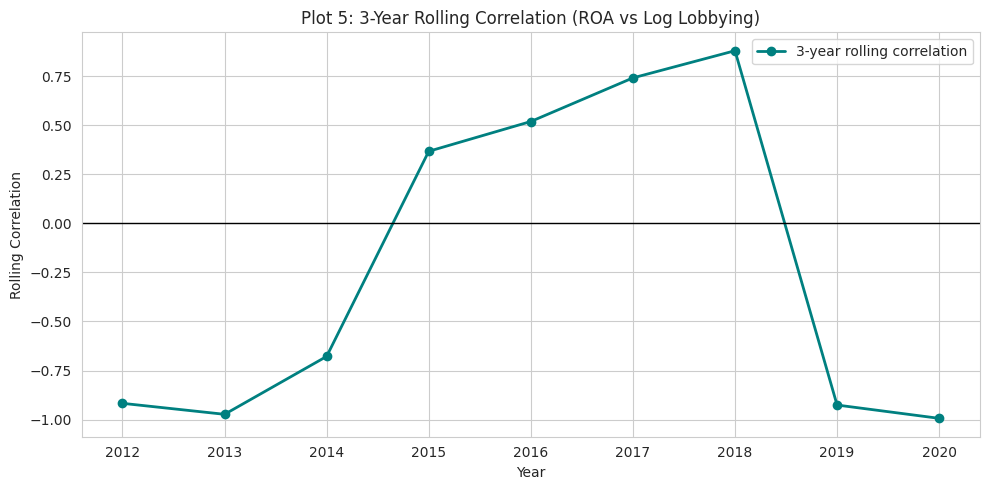

Saved Plot 5 to: results/figures/plot5_rolling_correlation.png
Lowest rolling corr: -0.99 in year 2020
Highest rolling corr: 0.88 in year 2018


,year,avg_roa,avg_driver,rolling_corr
0,2010,1.219514,11.579245,NaN
1,2011,-0.042698,11.879076,NaN
2,2012,0.919083,11.509118,-0.917424
3,2013,0.279872,11.680253,-0.973433
4,2014,0.246401,12.420870,-0.678163
5,2015,0.228918,10.851621,0.367919
6,2016,0.510049,12.363151,0.519862
7,2017,0.190590,11.739642,0.742247
8,2018,0.218776,12.078004,0.880885
9,2019,1.846005,11.157443,-0.926152


In [11]:
# Plot 5 (Alternative B): Rolling Correlation Analysis
rolling_window = 3  # 3-year window is suitable for annual data with a short sample

rolling_df = (
    df.groupby("year", as_index=False)
    .agg(avg_roa=("roa", "mean"), avg_driver=("log_lobbying", "mean"))
    .sort_values("year")
)

rolling_df["rolling_corr"] = (
    rolling_df["avg_roa"]
    .rolling(window=rolling_window, min_periods=rolling_window)
    .corr(rolling_df["avg_driver"])
)

plt.figure(figsize=(10, 5))
plt.plot(
    rolling_df["year"],
    rolling_df["rolling_corr"],
    marker="o",
    linewidth=2,
    color="teal",
    label=f"{rolling_window}-year rolling correlation",
)
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Plot 5: {rolling_window}-Year Rolling Correlation (ROA vs Log Lobbying)")
plt.xlabel("Year")
plt.ylabel("Rolling Correlation")
plt.legend()
plt.tight_layout()

plot5_path = FIGURES_DIR / "plot5_rolling_correlation.png"
plt.savefig(plot5_path, dpi=300, bbox_inches="tight")
plt.show()

valid_rc = rolling_df.dropna(subset=["rolling_corr"])
if not valid_rc.empty:
    min_idx = valid_rc["rolling_corr"].idxmin()
    max_idx = valid_rc["rolling_corr"].idxmax()
    print(f"Saved Plot 5 to: {plot5_path}")
    print(
        f"Lowest rolling corr: {valid_rc.loc[min_idx, 'rolling_corr']:.2f} "
        f"in year {int(valid_rc.loc[min_idx, 'year'])}"
    )
    print(
        f"Highest rolling corr: {valid_rc.loc[max_idx, 'rolling_corr']:.2f} "
        f"in year {int(valid_rc.loc[max_idx, 'year'])}"
    )
else:
    print(f"Saved Plot 5 to: {plot5_path}")
    print("Not enough periods to compute rolling correlation with this window.")

rolling_df

Plot 5 interpretation:

Saved figure: results/figures/M2/plot5_rolling_correlation.png

The rolling correlation indicates that the lobbying-profitability relationship changes sign and strength over time, which economically points to regime dependence rather than a stable return to political spending. In expansionary or policy-active periods, lobbying may help firms secure favorable outcomes, while in other periods it may mainly reflect defensive or compliance spending with limited profit impact. This time variation also implies that pooling all years into one estimate can mask economically important shifts in the underlying mechanism. For M3, the evidence supports interactions with period conditions and subsample analysis to separate high-payoff from low-payoff regimes.

/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


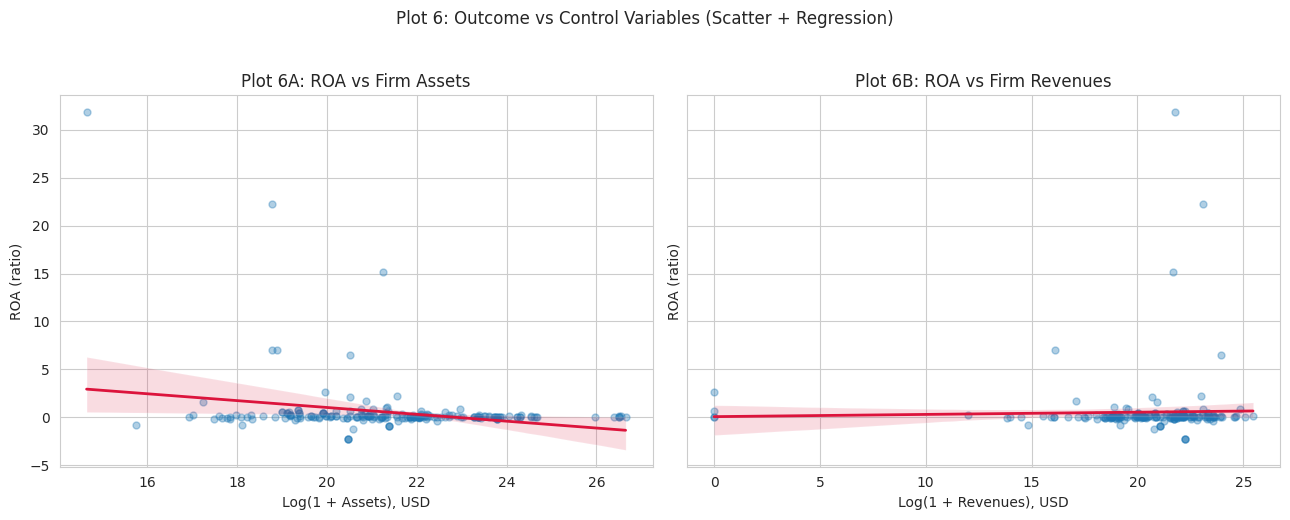

Saved Plot 6 to: results/figures/plot6_control_scatter_regression.png
corr(ROA, log Assets) = -0.25
corr(ROA, log Revenues) = 0.03


In [ ]:
# Plot 6: Factor/Control Variable Scatter Plots (Outcome vs Controls)
plot6_df = df.copy()

# Safe logs: values <= -1 are invalid for log1p, so mark them missing
plot6_df["log_assets"] = np.where(plot6_df["Assets"] > -1, np.log1p(plot6_df["Assets"]), np.nan)
plot6_df["log_revenues"] = np.where(plot6_df["Revenues"] > -1, np.log1p(plot6_df["Revenues"]), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sns.regplot(
    data=plot6_df.dropna(subset=["log_assets", "roa"]),
    x="log_assets",
    y="roa",
    scatter_kws={"alpha": 0.35, "s": 25},
    line_kws={"color": "crimson", "linewidth": 2},
    ax=axes[0],
)
axes[0].set_title("Plot 6A: ROA vs Firm Assets")
axes[0].set_xlabel("Log(1 + Assets), USD")
axes[0].set_ylabel("ROA (ratio)")

sns.regplot(
    data=plot6_df.dropna(subset=["log_revenues", "roa"]),
    x="log_revenues",
    y="roa",
    scatter_kws={"alpha": 0.35, "s": 25},
    line_kws={"color": "crimson", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Plot 6B: ROA vs Firm Revenues")
axes[1].set_xlabel("Log(1 + Revenues), USD")
axes[1].set_ylabel("ROA (ratio)")

scatter_fit_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="gray", alpha=0.5, markersize=6, label="Firm observations"),
    Line2D([0], [0], color="crimson", linewidth=2, label="Linear fit"),
]
for ax in axes:
    ax.legend(handles=scatter_fit_legend, loc="best")

plt.suptitle("Plot 6: Outcome vs Control Variables (Scatter + Regression)", y=1.03)
plt.tight_layout()

plot6_path = FIGURES_DIR / "plot6_control_scatter_regression.png"
plt.savefig(plot6_path, dpi=300, bbox_inches="tight")
plt.show()

# Quick bivariate diagnostics for interpretation
r_roa_assets = plot6_df[["roa", "log_assets"]].dropna().corr().loc["roa", "log_assets"]
r_roa_revenues = plot6_df[["roa", "log_revenues"]].dropna().corr().loc["roa", "log_revenues"]
print(f"Saved Plot 6 to: {plot6_path}")
print(f"corr(ROA, log Assets) = {r_roa_assets:.2f}")
print(f"corr(ROA, log Revenues) = {r_roa_revenues:.2f}")

Plot 6 interpretation:

Saved figure: results/figures/M2/plot6_control_scatter_regression.png

The weak bivariate slopes between ROA and size controls imply that scale alone does not mechanically translate into higher profitability in this sample. Economically, larger firms may have offsetting forces, including greater market power but also heavier capital intensity, regulatory burden, or organizational inefficiency, producing modest net ROA differences. The wide dispersion reinforces that firms with similar size can realize very different returns depending on strategy, sector, and operating environment. For M3, this means size controls are necessary for identification, but they should not be expected to absorb most profitability variation on their own.

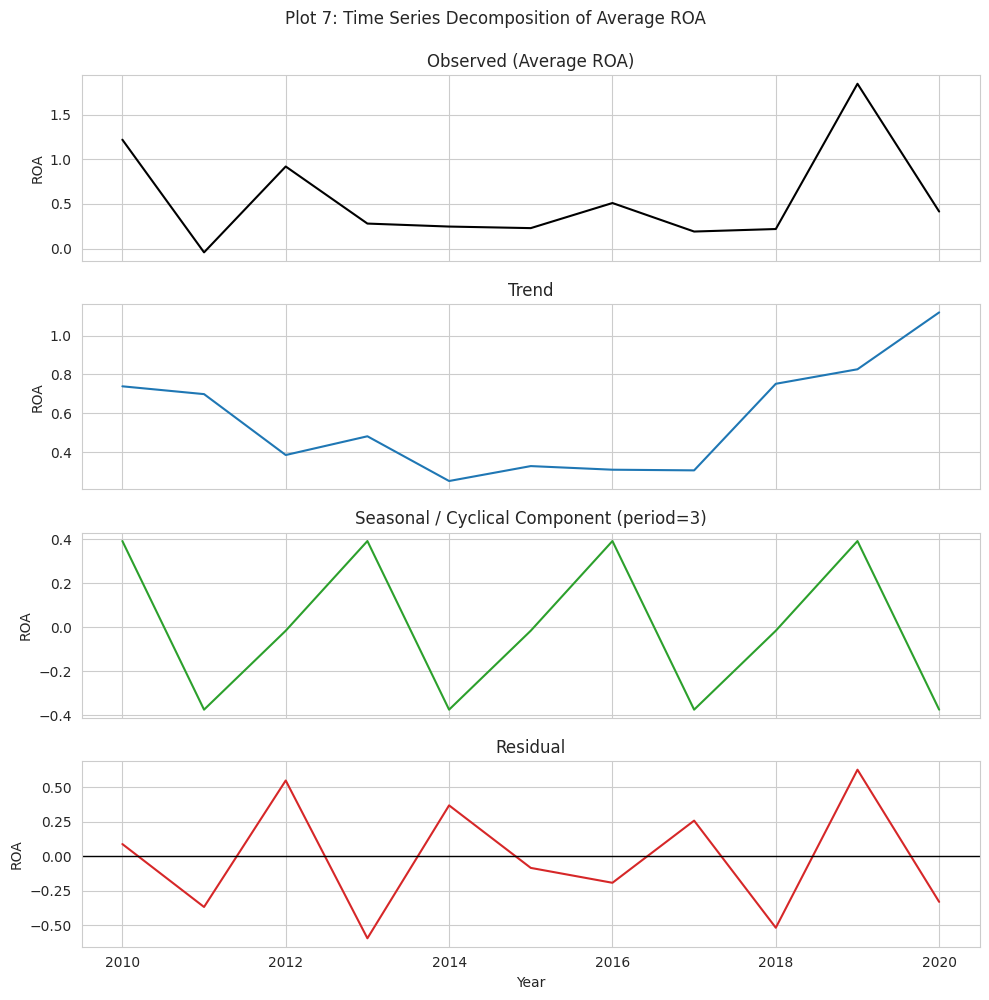

Saved Plot 7 to: results/figures/plot7_time_series_decomposition.png
Trend start -> end: 0.739 -> 1.119
Residual standard deviation: 0.426


In [ ]:
# Plot 7: Time Series Decomposition (Outcome)
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate panel to annual outcome time series
ts_df = (
    df.groupby("year", as_index=False)["roa"]
    .mean()
    .sort_values("year")
)
ts = pd.Series(ts_df["roa"].values, index=pd.Index(ts_df["year"].astype(int), name="year"))

# Annual data has no true within-year seasonality; period=3 captures short-cycle movement
decomp_period = 3
decomp = seasonal_decompose(ts, model="additive", period=decomp_period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axes[0].plot(ts.index, decomp.observed, color="black", label="Observed ROA")
axes[0].set_title("Observed (Average ROA)")
axes[0].set_ylabel("ROA")
axes[0].legend(loc="best")

axes[1].plot(ts.index, decomp.trend, color="tab:blue", label="Trend component")
axes[1].set_title("Trend")
axes[1].set_ylabel("ROA")
axes[1].legend(loc="best")

axes[2].plot(ts.index, decomp.seasonal, color="tab:green", label="Cyclical component")
axes[2].set_title(f"Seasonal / Cyclical Component (period={decomp_period})")
axes[2].set_ylabel("ROA")
axes[2].legend(loc="best")

axes[3].plot(ts.index, decomp.resid, color="tab:red", label="Residual")
axes[3].axhline(0, color="black", linewidth=1, label="Zero baseline")
axes[3].set_title("Residual")
axes[3].set_ylabel("ROA")
axes[3].set_xlabel("Year")
axes[3].legend(loc="best")

fig.suptitle("Plot 7: Time Series Decomposition of Average ROA", y=0.995)
plt.tight_layout()

plot7_decomp_path = FIGURES_DIR / "plot7_time_series_decomposition.png"
plt.savefig(plot7_decomp_path, dpi=300, bbox_inches="tight")
plt.show()

# Small diagnostics for interpretation
trend_start = float(decomp.trend.dropna().iloc[0])
trend_end = float(decomp.trend.dropna().iloc[-1])
resid_sd = float(decomp.resid.dropna().std())

print(f"Saved Plot 7 to: {plot7_decomp_path}")
print(f"Trend start -> end: {trend_start:.3f} -> {trend_end:.3f}")
print(f"Residual standard deviation: {resid_sd:.3f}")

Plot 7 interpretation:

Saved figure: results/figures/M2/plot7_time_series_decomposition.png

The decomposition suggests a relatively stable long-run profitability baseline with short-cycle fluctuations and residual shocks. Economically, this means firm profitability appears anchored by persistent fundamentals while policy, demand, and financing conditions generate temporary deviations around trend. Because residual volatility remains material, unobserved shocks can still bias simple lobbying-profitability comparisons if not controlled. For M3, this interpretation supports year effects and robustness checks for extreme years so the estimated lobbying coefficient reflects behavior beyond aggregate cyclical noise.

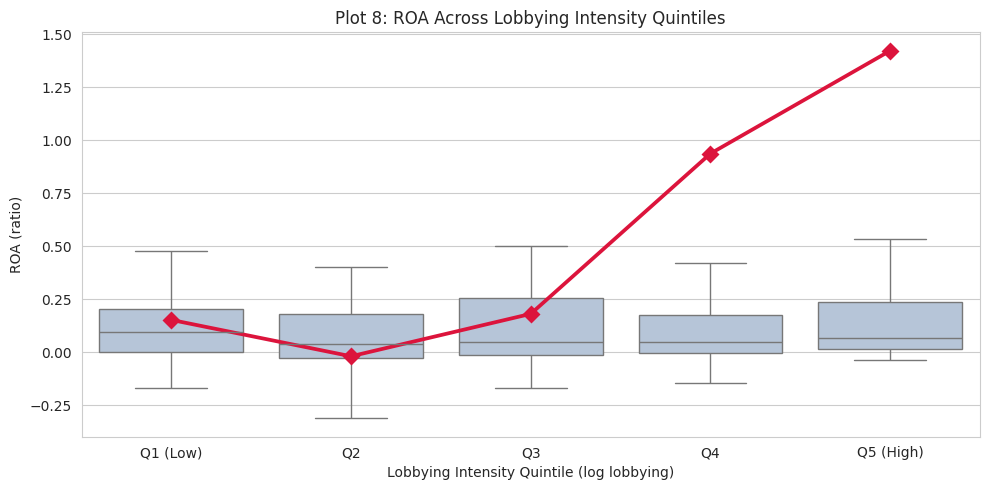

Saved Plot 8 to: results/figures/plot8_outcome_by_driver_quintile.png
Mean ROA by lobbying quintile:
lobbying_quintile
Q1 (Low)     0.153
Q2          -0.018
Q3           0.182
Q4           0.937
Q5 (High)    1.422
Name: roa, dtype: float64


In [ ]:
# Plot 8: Outcome by Driver Quintile (Nonlinearity Check)
plot8_df = df[["roa", "log_lobbying"]].dropna().copy()
plot8_df["lobbying_quintile"] = pd.qcut(
    plot8_df["log_lobbying"],
    q=5,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"],
    duplicates="drop",
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=plot8_df,
    x="lobbying_quintile",
    y="roa",
    color="lightsteelblue",
    showfliers=False,
)
sns.pointplot(
    data=plot8_df,
    x="lobbying_quintile",
    y="roa",
    estimator=np.mean,
    errorbar=None,
    color="crimson",
    markers="D",
    linestyles="-",
)
plt.title("Plot 8: ROA Across Lobbying Intensity Quintiles")
plt.xlabel("Lobbying Intensity Quintile (log lobbying)")
plt.ylabel("ROA (ratio)")
quintile_legend = [
    Patch(facecolor="lightsteelblue", label="ROA distribution (boxplot)"),
    Line2D([0], [0], color="crimson", marker="D", linewidth=2, label="Mean ROA"),
]
plt.legend(handles=quintile_legend, loc="best")
plt.tight_layout()

plot8_path = FIGURES_DIR / "plot8_outcome_by_driver_quintile.png"
plt.savefig(plot8_path, dpi=300, bbox_inches="tight")
plt.show()

plot8_means = plot8_df.groupby("lobbying_quintile", observed=False)["roa"].mean()
print(f"Saved Plot 8 to: {plot8_path}")
print("Mean ROA by lobbying quintile:")
print(plot8_means.round(3))

Plot 8 interpretation:

Saved figure: results/figures/M2/plot8_outcome_by_driver_quintile.png

Comparing ROA across lobbying quintiles tests whether the economic return to lobbying is linear or concentrated at specific spending levels. A monotonic pattern would suggest broadly increasing marginal benefits, while flat middle ranges or non-monotonic shifts would indicate thresholds, diminishing returns, or selection into lobbying intensity. Economically, this matters because high-lobbying firms may be paying for access protection rather than buying proportional profit gains each additional dollar. For M3, the shape evidence motivates nonlinear specifications such as squared lobbying terms or grouped-effect models.

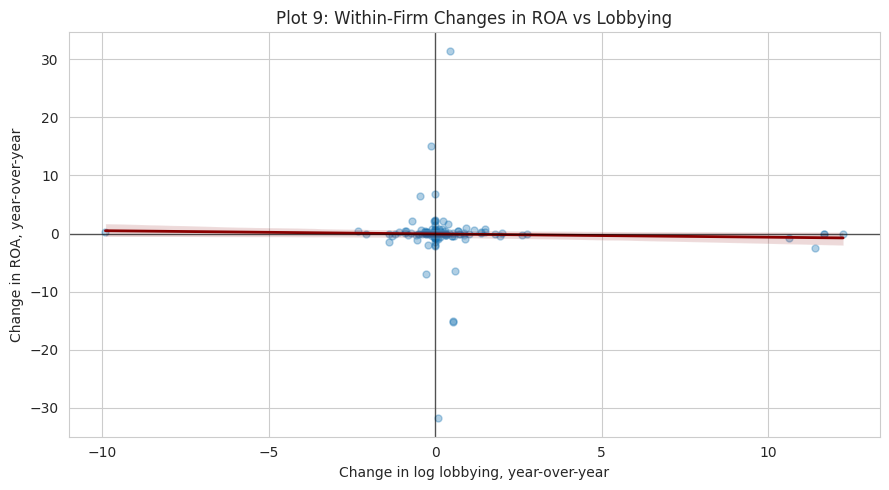

Saved Plot 9 to: results/figures/plot9_within_firm_changes.png
corr(Delta ROA, Delta log lobbying) = -0.029
N (within-firm changes) = 169


In [ ]:
# Plot 9: Within-Firm Changes (Delta ROA vs Delta Driver)
if "gvkey" in df.columns:
    entity_col_plot9 = "gvkey"
elif "cik" in df.columns:
    entity_col_plot9 = "cik"
else:
    raise ValueError("No entity id column found. Expected 'gvkey' or 'cik'.")

plot9_df = df[[entity_col_plot9, "year", "roa", "log_lobbying"]].dropna().copy()
plot9_df = plot9_df.sort_values([entity_col_plot9, "year"])
plot9_df["d_roa"] = plot9_df.groupby(entity_col_plot9)["roa"].diff()
plot9_df["d_log_lobbying"] = plot9_df.groupby(entity_col_plot9)["log_lobbying"].diff()
plot9_df = plot9_df.dropna(subset=["d_roa", "d_log_lobbying"] )

plt.figure(figsize=(9, 5))
sns.regplot(
    data=plot9_df,
    x="d_log_lobbying",
    y="d_roa",
    scatter_kws={"alpha": 0.35, "s": 25},
    line_kws={"color": "darkred", "linewidth": 2},
)
plt.axhline(0, color="black", linewidth=1, alpha=0.6)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.title("Plot 9: Within-Firm Changes in ROA vs Lobbying")
plt.xlabel("Change in log lobbying, year-over-year")
plt.ylabel("Change in ROA, year-over-year")
within_firm_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="gray", alpha=0.5, markersize=6, label="Firm-year changes"),
    Line2D([0], [0], color="darkred", linewidth=2, label="Linear fit"),
    Line2D([0], [0], color="black", linewidth=1, label="Zero-change baseline"),
]
plt.legend(handles=within_firm_legend, loc="best")
plt.tight_layout()

plot9_path = FIGURES_DIR / "plot9_within_firm_changes.png"
plt.savefig(plot9_path, dpi=300, bbox_inches="tight")
plt.show()

corr_delta = plot9_df["d_roa"].corr(plot9_df["d_log_lobbying"] )
print(f"Saved Plot 9 to: {plot9_path}")
print(f"corr(Delta ROA, Delta log lobbying) = {corr_delta:.3f}")
print(f"N (within-firm changes) = {len(plot9_df)}")

Plot 9 interpretation:

Saved figure: results/figures/M2/plot9_within_firm_changes.png

Within-firm differencing isolates short-run co-movements by removing time-invariant firm traits, so the slope here is closer to an incremental economic response than a cross-sectional level comparison. If changes in lobbying are only weakly associated with changes in ROA, the economic effect in the short run is likely modest relative to other operational shocks. This is consistent with lobbying acting as a medium-horizon strategic investment rather than a one-year profit lever. For M3, the result strengthens the case for firm fixed effects and first-difference robustness to reduce bias from persistent firm heterogeneity.

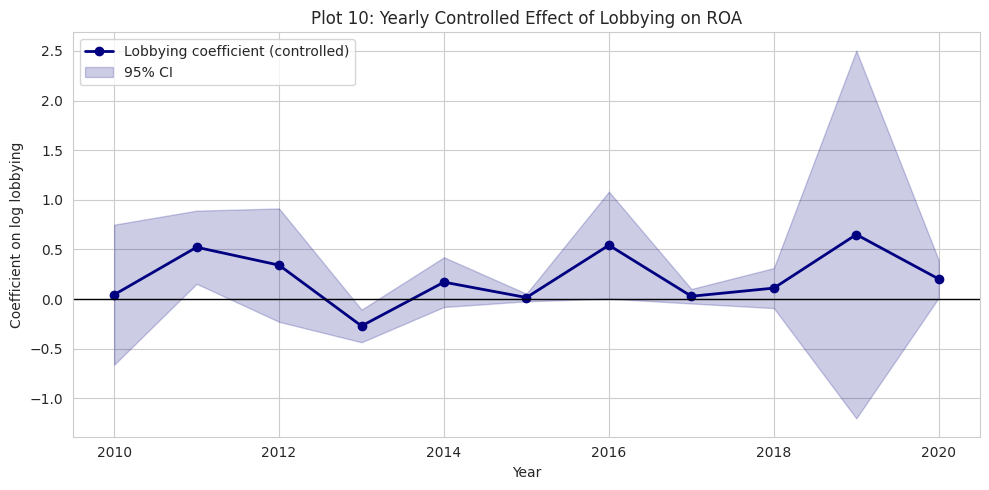

Saved Plot 10 to: results/figures/plot10_yearly_controlled_lobbying_effect.png
Average yearly lobbying coefficient: 0.2144
Years with negative coefficient: 1


,year,coef,se,n_obs,ci_low,ci_high
0,2010,0.043914,0.359985,14,-0.661655,0.749484
1,2011,0.522280,0.187937,19,0.153924,0.890635
2,2012,0.341943,0.291297,18,-0.228999,0.912886
3,2013,-0.270939,0.083813,18,-0.435213,-0.106665
4,2014,0.170586,0.127815,15,-0.079932,0.421104
5,2015,0.015632,0.019502,14,-0.022592,0.053856
6,2016,0.542861,0.274936,17,0.003986,1.081735
7,2017,0.028580,0.037235,18,-0.044402,0.101561
8,2018,0.110613,0.102873,15,-0.091018,0.312244
9,2019,0.650251,0.944775,16,-1.201507,2.502010


In [20]:
# Plot 10: Yearly Controlled Effect of Lobbying on ROA
import statsmodels.api as sm

plot10_df = df[["year", "roa", "log_lobbying", "Assets", "Revenues"]].copy()
plot10_df["log_assets"] = np.nan
plot10_df.loc[plot10_df["Assets"] > -1, "log_assets"] = np.log1p(
    plot10_df.loc[plot10_df["Assets"] > -1, "Assets"]
)
plot10_df["log_revenues"] = np.nan
plot10_df.loc[plot10_df["Revenues"] > -1, "log_revenues"] = np.log1p(
    plot10_df.loc[plot10_df["Revenues"] > -1, "Revenues"]
)
plot10_df = plot10_df.dropna(subset=["year", "roa", "log_lobbying", "log_assets", "log_revenues"])

coef_rows = []
min_obs_per_year = 10

for year, g in plot10_df.groupby("year"):
    if len(g) < min_obs_per_year:
        continue
    # Skip years with no variation in key regressor
    if g["log_lobbying"].nunique() < 2:
        continue

    X = g[["log_lobbying", "log_assets", "log_revenues"]]
    X = sm.add_constant(X)
    y = g["roa"]

    model = sm.OLS(y, X).fit()
    coef = model.params["log_lobbying"]
    se = model.bse["log_lobbying"]
    coef_rows.append(
        {
            "year": int(year),
            "coef": float(coef),
            "se": float(se),
            "n_obs": int(len(g)),
            "ci_low": float(coef - 1.96 * se),
            "ci_high": float(coef + 1.96 * se),
        }
    )

coef_df = pd.DataFrame(coef_rows).sort_values("year")

plt.figure(figsize=(10, 5))
plt.plot(
    coef_df["year"],
    coef_df["coef"],
    marker="o",
    linewidth=2,
    color="navy",
    label="Lobbying coefficient (controlled)",
)
plt.fill_between(
    coef_df["year"],
    coef_df["ci_low"],
    coef_df["ci_high"],
    color="navy",
    alpha=0.2,
    label="95% CI",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Plot 10: Yearly Controlled Effect of Lobbying on ROA")
plt.xlabel("Year")
plt.ylabel("Coefficient on log lobbying")
plt.legend()
plt.tight_layout()

plot10_path = FIGURES_DIR / "plot10_yearly_controlled_lobbying_effect.png"
plt.savefig(plot10_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Plot 10 to: {plot10_path}")
print("Average yearly lobbying coefficient:", round(coef_df["coef"].mean(), 4))
print("Years with negative coefficient:", int((coef_df["coef"] < 0).sum()))
coef_df

Plot 10 interpretation:

Saved figure: results/figures/M2/plot10_yearly_controlled_lobbying_effect.png

Year-specific controlled coefficients show that the economic payoff to lobbying is not constant over time, even after adjusting for major size controls. Sign switches and wide confidence bands indicate that contextual factors, such as policy windows, enforcement intensity, and macro financing conditions, likely mediate realized returns. Economically, this argues against interpreting a single average slope as a structural parameter for all periods. For M3, the evidence supports heterogeneous-effect modeling across years and careful interpretation of average effects as period-weighted summaries rather than universal treatment effects.